#Setup & Acquisition

In [24]:
import os
import shutil
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Konfigurasi Kaggle
source_path = 'kaggle.json'
dot_kaggle_dir = os.path.expanduser('~/.kaggle')

if os.path.exists(source_path):
    if not os.path.exists(dot_kaggle_dir):
        os.makedirs(dot_kaggle_dir)
    # Menyalin file ke folder
    shutil.copy(source_path, os.path.join(dot_kaggle_dir, 'kaggle.json'))
else:
    print("Error: File kaggle.json tidak ada ")

# 2. Membuat Struktur Folder
os.makedirs('data/raw', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# 3. Download Dataset via API
!kaggle datasets download -d amirmohammdjalili/soil-moisture-dataset --force

# 4. Ekstrak Dataset Menggunakan Python (Lebih Stabil di Windows)
with zipfile.ZipFile('soil-moisture-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data/raw/')

print("Proses download dan ekstraksi selesai.")

Dataset URL: https://www.kaggle.com/datasets/amirmohammdjalili/soil-moisture-dataset
License(s): unknown

Proses download dan ekstraksi selesai.



  0%|          | 0.00/90.9k [00:00<?, ?B/s]
100%|██████████| 90.9k/90.9k [00:00<00:00, 536kB/s]
100%|██████████| 90.9k/90.9k [00:00<00:00, 533kB/s]


#Processing & Analysis

In [25]:
# 4.Data Mentah
df = pd.read_csv('data/raw/plant_vase1.CSV')

#5.Exploratory Data Analysis (EDA)
print("STRUKTUR DATA")

df.info()

print("STATISTIK DESKRIPTIF (df.describe)")
# Menampilkan rata-rata, min, max, dan kuartil untuk data numerik
display(df.describe())

print("CEK DATA KOSONG (Missing Values)")
# Menghitung jumlah nilai NaN/Null di setiap kolom
print(df.isnull().sum())


STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4117 entries, 0 to 4116
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       4117 non-null   int64  
 1   month      4117 non-null   int64  
 2   day        4117 non-null   int64  
 3   hour       4117 non-null   int64  
 4   minute     4117 non-null   int64  
 5   second     4117 non-null   int64  
 6   moisture0  4117 non-null   float64
 7   moisture1  4117 non-null   float64
 8   moisture2  4117 non-null   float64
 9   moisture3  4117 non-null   float64
 10  moisture4  4117 non-null   float64
 11  irrgation  4117 non-null   bool   
dtypes: bool(1), float64(5), int64(6)
memory usage: 358.0 KB
STATISTIK DESKRIPTIF (df.describe)


,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4
count,4117.0,4117.0,4117.000000,4117.000000,4117.000000,4117.000000,4117.000000,4117.000000,4117.000000,4117.000000,4117.000000
mean,2020.0,3.0,7.885839,11.109060,29.461744,31.570318,0.444190,0.652142,0.679390,0.325732,0.020816
std,0.0,0.0,0.844629,6.827032,17.315045,16.107940,0.149481,0.022218,0.048444,0.197201,0.002738
min,2020.0,3.0,6.000000,0.000000,0.000000,0.000000,0.170000,0.600000,0.580000,0.080000,0.020000
25%,2020.0,3.0,7.000000,5.000000,14.000000,19.000000,0.330000,0.630000,0.640000,0.110000,0.020000
50%,2020.0,3.0,8.000000,11.000000,29.000000,33.000000,0.490000,0.650000,0.700000,0.330000,0.020000
75%,2020.0,3.0,9.000000,17.000000,44.000000,45.000000,0.560000,0.670000,0.720000,0.530000,0.020000
max,2020.0,3.0,9.000000,23.000000,59.000000,59.000000,0.700000,0.690000,0.740000,0.600000,0.030000


CEK DATA KOSONG (Missing Values)
year         0
month        0
day          0
hour         0
minute       0
second       0
moisture0    0
moisture1    0
moisture2    0
moisture3    0
moisture4    0
irrgation    0
dtype: int64


Data Cleaning (Outliers & Transformation)
memeriksa semua sensor dan akan menyimpan baris yang berada dalam rentang yang valid


In [ ]:
# 5.kolom sensor yang akan diperiksa
sensor_cols = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4']

valid_mask = (df[sensor_cols] >= 0) & (df[sensor_cols] <= 1)

df_cleaned = df[valid_mask.all(axis=1)].copy()


df_cleaned['timestamp'] = pd.to_datetime(df_cleaned[['year', 'month', 'day', 'hour', 'minute', 'second']])


df_final = df_cleaned.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'second'])
cols = ['timestamp'] + [c for c in df_final.columns if c != 'timestamp']
df_final = df_final[cols]

print(f"Pembersihan Selesai (Metode: Manual Thresholding)")
print(f"Data Awal: {len(df)} | Data Bersih: {len(df_final)}")


print(f"Data awal: {len(df)} baris | Data bersih: {len(df_final)} baris.")

Pembersihan Selesai (Metode: Manual Thresholding)
Data Awal: 4117 | Data Bersih: 4117
Data awal: 4117 baris | Data bersih: 4117 baris.


Visual Analysis

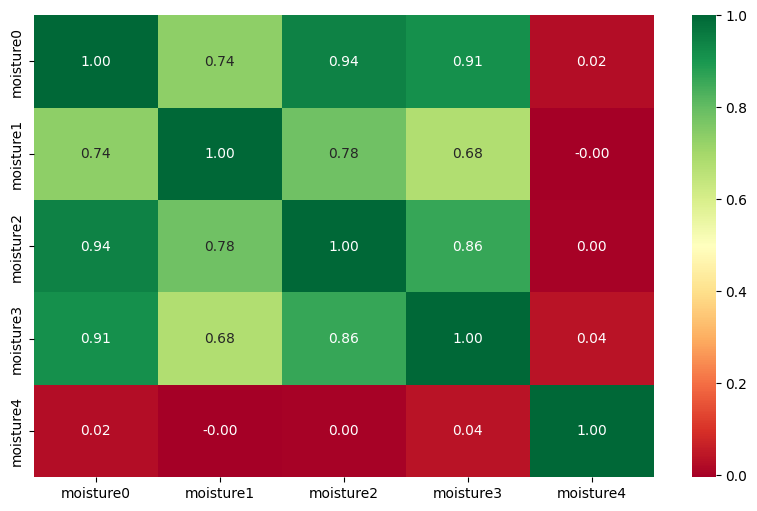

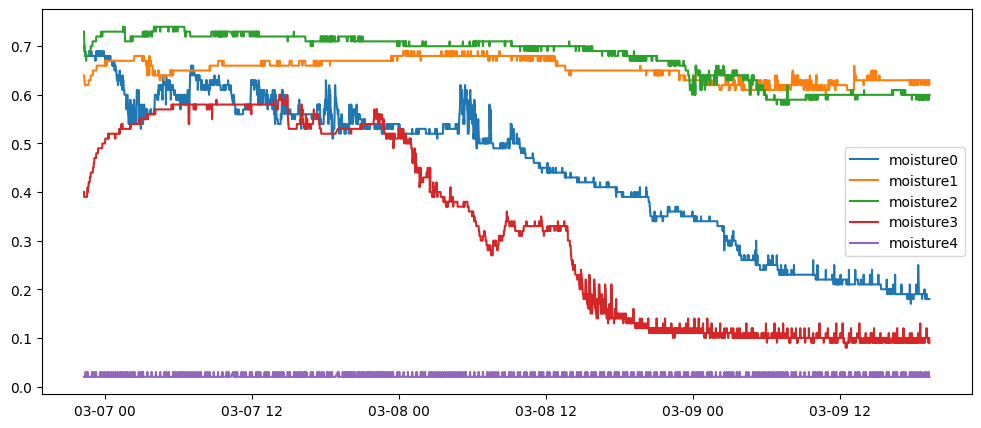

In [27]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_final[sensor_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.show()

# Time Series
plt.figure(figsize=(12, 5))
for col in sensor_cols:
    plt.plot(df_final['timestamp'], df_final[col], label=col)
plt.legend()
plt.show()

export

In [28]:
# 14.Simpan ke folder outputs
df_final.to_csv('outputs/cleaned_data.csv', index=False)
print("SUKSES: File 'cleaned_data.csv' telah tersedia di folder 'outputs'.")

SUKSES: File 'cleaned_data.csv' telah tersedia di folder 'outputs'.
